1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import pickle

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...


True

2. Generate the dataset

In [4]:
# Load the datasets
fake = pd.read_csv('../data/Fake.csv')
true = pd.read_csv('../data/True.csv')


In [5]:
# Label the datasets
fake['label'] = 0
true['label'] = 1

# Combine the datasets
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,title,text,subject,date,label
0,Venezuela government and opposition to resume ...,CARACAS (Reuters) - Venezuela s government and...,worldnews,"November 10, 2017",1
1,RUSSIAN TV HOST TRASHES MOOCH: Obama’s Spent $...,"She s such an easy target, it s almost like th...",left-news,"Feb 18, 2016",0
2,"Trump to meet Australian PM, relations straine...",SYDNEY/WASHINGTON (Reuters)) - U.S. President ...,politicsNews,"April 25, 2017",1
3,Howard Stern: Having Trump On My Show To Deme...,"Time and time again, Donald Trump appeared on ...",News,"October 17, 2016",0
4,France's Macron says U.S. interests to be harm...,PARIS (Reuters) - French President Emmanuel Ma...,politicsNews,"June 1, 2017",1


3. Data Exploration

In [6]:
print(data.shape)

(44898, 5)


In [7]:
print(data['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [8]:
print (data.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')


In [9]:
# check for missing values
print(data.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


4. Data Visualization

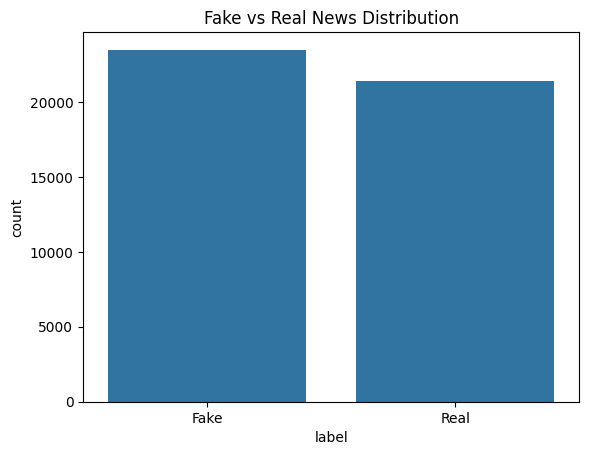

In [10]:
sns.countplot(x="label", data=data)

plt.xticks([0,1], ["Fake", "Real"])

plt.title("Fake vs Real News Distribution")

plt.show()

5. Text Length Analysis

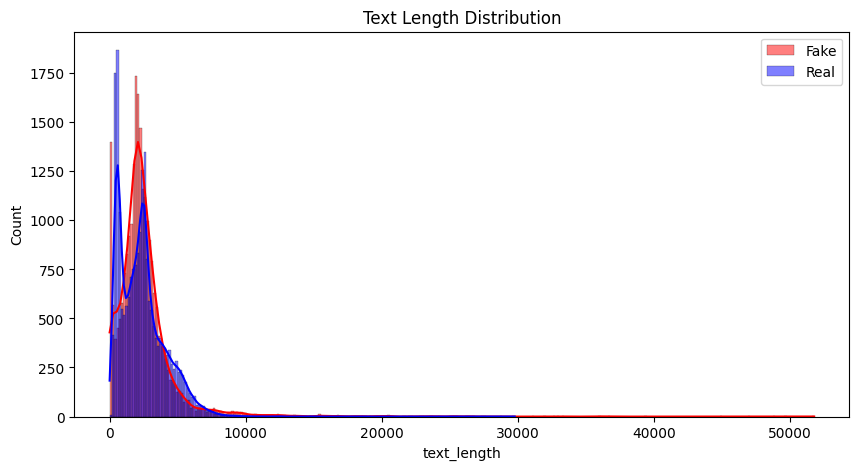

In [11]:
# create a new feature for text length
data["text_length"] = data["text"].apply(len)

# visualize the distribution of text length
plt.figure(figsize=(10,5))

sns.histplot(data[data["label"] == 0]["text_length"],
             color='red',
             label='Fake',
             kde=True)

sns.histplot(data[data["label"] == 1]["text_length"],
             color='blue',
             label='Real',
             kde=True)

plt.legend()

plt.title("Text Length Distribution")

plt.show()

6. Data Cleaning / NLP Preprocessing

In [12]:
# Initialize the stop words and lemmatizer (these will be used in the text preprocessing step)
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

#Clean the text data removing URLs, HTML tags, non-alphabetic characters, punctuation, and stop words, and lemmatizing the words
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
# Apply the cleaning function to the text data
data["clean_text"] = data["text"].apply(clean_text)

7. Feature Engineering

In [14]:
# Vectorize the text data using TF-IDF
# TF-IDF (Term Frequency-Inverse Document Frequency) is a common technique for converting text data into numerical features that can be used for machine learning models. It assigns a weight to each word in the text based on its frequency in the document and its rarity across all documents. This helps to highlight important words while downplaying common words that may not carry much meaning.
vectorizer = TfidfVectorizer(
    max_features=10000
)

X = vectorizer.fit_transform(data["clean_text"])

y = data["label"]

In [15]:
#view the shape of the feature matrix
print(X.shape)

(44898, 10000)


In [17]:
# Top important words
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:100])

['aaron' 'abadi' 'abandon' 'abandoned' 'abandoning' 'abbas' 'abbott' 'abc'
 'abd' 'abdel' 'abducted' 'abdul' 'abdullah' 'abe' 'abedin' 'abid' 'abide'
 'abiding' 'ability' 'able' 'aboard' 'abolish' 'aborted' 'abortion'
 'abraham' 'abroad' 'abrupt' 'abruptly' 'absence' 'absent' 'absentee'
 'absolute' 'absolutely' 'absurd' 'absurdity' 'abu' 'abuse' 'abused'
 'abuser' 'abusing' 'abusive' 'aca' 'academic' 'academy' 'accelerate'
 'accelerated' 'accept' 'acceptable' 'acceptance' 'accepted' 'accepting'
 'accepts' 'access' 'accessed' 'accessible' 'accession' 'accident'
 'accidental' 'accidentally' 'accommodate' 'accommodation' 'accompanied'
 'accompanying' 'accomplice' 'accomplish' 'accomplished' 'accomplishment'
 'accord' 'accordance' 'according' 'accordingly' 'account'
 'accountability' 'accountable' 'accounted' 'accounting' 'accuracy'
 'accurate' 'accurately' 'accusation' 'accuse' 'accused' 'accuser'
 'accuses' 'accusing' 'achieve' 'achieved' 'achievement' 'achieving'
 'acknowledge' 'acknowl

In [18]:
# Most important words based on average TF-IDF scores
tfidf_scores = np.asarray(X.mean(axis=0)).ravel()

scores_df = pd.DataFrame({
    "word": feature_names,
    "score": tfidf_scores
})

top_words = scores_df.sort_values(
    by="score",
    ascending=False
).head(20)

print(top_words)

            word     score
9266       trump  0.056690
7816        said  0.042192
6852   president  0.024077
8523       state  0.024034
9909       would  0.020761
7494  republican  0.020743
1596     clinton  0.018902
6516      people  0.018051
6117       obama  0.017047
9949        year  0.016404
4297       house  0.016182
7601     reuters  0.015904
6201         one  0.015341
2730      donald  0.014831
3888  government  0.014447
6003         new  0.014210
2918    election  0.014193
9803       white  0.013978
6440       party  0.013824
347     american  0.013039


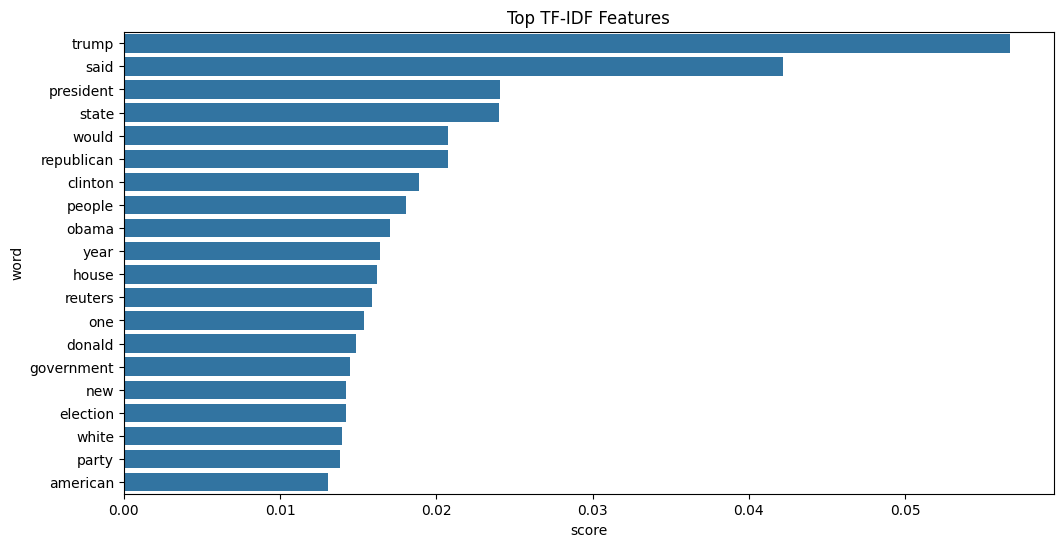

In [19]:
# visualize the top important features
plt.figure(figsize=(12,6))

sns.barplot(
    x="score",
    y="word",
    data=top_words
)

plt.title("Top TF-IDF Features")

plt.show()

8. Train / Test / Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

9. Model Training (3 models are training for select the best model)

In [21]:
# Logistic Regression
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
# model re-training with best parameters
lr_model = LogisticRegression(
    max_iter=500,
    random_state=42
)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
# Random Forest
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
# Model re-training with best parameters
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [23]:
# Naive Bayes
nb_model = MultinomialNB()  

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
# Model re-training with best parameters
nb_model = MultinomialNB(alpha=0.1)

nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.1
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


10. Model Evaluation

In [27]:
# Logistic Regression Evaluation
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy:
0.9869710467706013
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4678
           1       0.99      0.99      0.99      4302

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



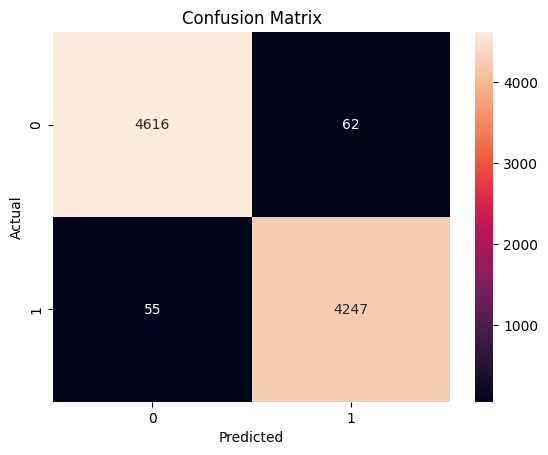

In [30]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [28]:
# Random Forest Evaluation
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:")

print(accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))


Random Forest Accuracy:
0.9967706013363029
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4678
           1       1.00      1.00      1.00      4302

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



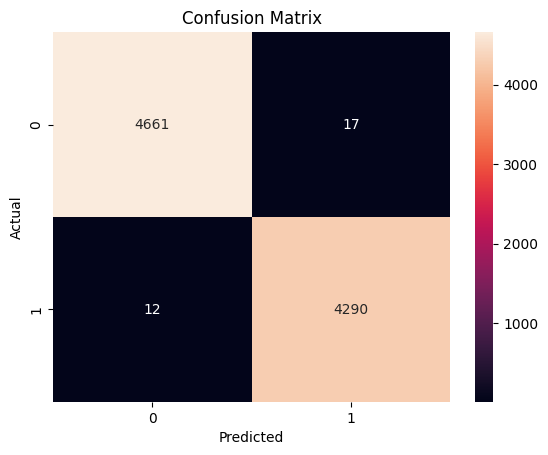

In [31]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [29]:
# Naive Bayes Evaluation    
nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:")

print(accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy:
0.9335189309576838
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      4678
           1       0.94      0.92      0.93      4302

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



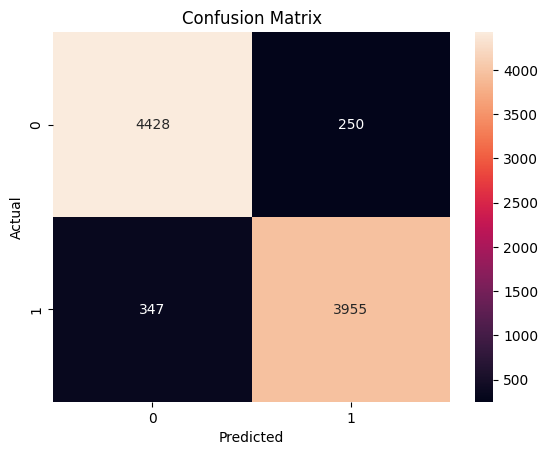

In [32]:
# Confusion Matrix for Naive Bayes

cm = confusion_matrix(y_test, nb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [33]:
# Compare all models

models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    print(f"{name} Accuracy: {accuracy}")

Logistic Regression Accuracy: 0.9869710467706013
Naive Bayes Accuracy: 0.9335189309576838
Random Forest Accuracy: 0.9967706013363029


11. Save the best model (Random Forest) using pickle

In [35]:
pickle.dump(
    rf_model,
    open("../models/model.pkl", "wb")
)

pickle.dump(
    vectorizer,
    open("../models/vectorizer.pkl", "wb")
)

12. Test saved model

In [37]:
loaded_model = pickle.load(
    open("../models/model.pkl", "rb")
)

loaded_vectorizer = pickle.load(
    open("../models/vectorizer.pkl", "rb")
)

In [38]:
# Test manually 

sample_news = """
Breaking news: Scientists discovered aliens on Earth.
"""

cleaned = clean_text(sample_news)

vector = loaded_vectorizer.transform([cleaned])

prediction = loaded_model.predict(vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("Real News")

Fake News


In [39]:
# Test the model overfitting by checking the training and test accuracy
train_pred = rf_model.predict(X_train)

test_pred = rf_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)

test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)

print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9998886352246784
Testing Accuracy: 0.9967706013363029
